In [1]:
import sys
from pathlib import Path
import os
import time
import pickle
import pandas as pd
from tqdm.auto import tqdm
import asyncio

# Добавляем backend в PYTHONPATH
BACKEND_DIR = Path.cwd().parent / 'backend'
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

# Импорты из проекта
from config import OPENAI_API_KEY, OPENAI_BASE_URL, TEMPERATURE, MAX_TOKENS
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage

# Функция извлечения ответа из выдачи решателя
from agents.solver import extract_answer

/home/tas/.cache/pypoetry/virtualenvs/ai-mas-hse-project-VtkJAIkS-py3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Вспомогательная функция извлечения токенов (для информации, если нужно)
def get_token_usage(response):
    if hasattr(response, 'usage_metadata') and response.usage_metadata:
        inp = response.usage_metadata.get("input_tokens", 0)
        out = response.usage_metadata.get("output_tokens", 0)
        return inp, out
    if hasattr(response, 'response_metadata'):
        token_usage = response.response_metadata.get("token_usage", {})
        inp = token_usage.get("prompt_tokens", 0)
        out = token_usage.get("completion_tokens", 0)
        return inp, out
    return 0, 0


def load_standard_dataset():
    """Загружает стандартный датасет задач."""
    with open(STANDARD_DATASET_PATH, 'rb') as f:
        data = pickle.load(f)
    df = pd.DataFrame(data)
    # Ожидаемые колонки: problem, answer, topic, difficulty, etc.
    # Если названия отличаются, адаптируйте под реальную структуру.
    # Переименуем для удобства
    df = df.rename(columns={'answer': 'ground_truth'})
    return df


def load_mcp_dataset():
    """Загружает датасет MCP-уравнений."""
    with open(MCP_DATASET_PATH, 'rb') as f:
        data = pickle.load(f)
    df = pd.DataFrame(data)
    df = df.rename(columns={'answer': 'ground_truth'})  # на всякий случай
    return df

# 1. Загрузка датасетов

In [3]:
# Пути к файлам датасетов (относительно корня проекта или папки notebooks)
DATASET_DIR = Path.cwd().parent / 'static_dataset'
STANDARD_DATASET_PATH = DATASET_DIR / 'list_dict_with_tasks_update.pkl'
MCP_DATASET_PATH = DATASET_DIR / 'mcp_equations.pkl'

standard_df = load_standard_dataset()
mcp_df = load_mcp_dataset()

print(f"Стандартный датасет: {len(standard_df)} задач")
print(f"MCP-датасет: {len(mcp_df)} задач")
standard_df.head(2)

Стандартный датасет: 147 задач
MCP-датасет: 110 задач


,id,topic,subtopic,complexity_level,problem,solution,ground_truth,complexity_level_text
0,30262,Алгебра и арифметика,Арифметика. Устный счет и т.п,2,"Из книги выпал кусок, первая страница которого...",,496 страниц (248 листов),Легкий
1,30289,Алгебра и арифметика,Четность и нечетность,2,Можно ли доску размером 5×5 заполнить доминошк...,"Общее количество клеток (25) не делится на 2, ...",Нельзя,Легкий


# 2. LLM-судья для сравнения ответов

In [4]:
# Модель для судьи (можно выбрать фиксированную мощную модель)
JUDGE_MODEL_ID = "deepseek/deepseek-v3.2"  # или "gpt-4o"

In [5]:
def create_judge_llm():
    """Создаёт LLM для судьи (не зависит от модели решателя)."""
    return ChatOpenAI(
        model=JUDGE_MODEL_ID,
        temperature=0.0,          # минимальная вариативность
        max_tokens=2000,            # хватит для YES/NO
        timeout=60,
        max_retries=2,
        api_key=OPENAI_API_KEY,
        base_url=OPENAI_BASE_URL,
    )

JUDGE_PROMPT = """
Ты математический эксперт. Сравни ответ решателя с правильным ответом и определи, эквивалентны ли они математически.

Ответ решателя (может содержать лишний текст):
{solver_answer}

Правильный ответ:
{ground_truth}

Правила:
- Извлеки финальный ответ из текста решателя (игнорируй объяснения, пометки «Ответ:», «x =»).
- Сравни математическую суть: упрости выражения, приведи к общему виду.
- Для уравнений/неравенств сравни множества корней/решений (порядок не важен).
- Числа сравнивай с учетом возможного округления (например, 3.1416 ≈ π, 1/3 ≈ 0.333).
- Если ответы математически идентичны – YES, иначе NO.

Выведи СТРОГО одно слово: YES или NO. Никаких пояснений.
"""

In [6]:
def llm_judge(solver_answer: str, ground_truth: str, judge_llm: ChatOpenAI) -> bool:
    """Возвращает True, если судья считает ответы эквивалентными."""
    # Если ответы идентичны, можно сразу вернуть True без вызова LLM (оптимизация)
    if solver_answer.strip() == ground_truth.strip():
        return True

    prompt = JUDGE_PROMPT.format(solver_answer=solver_answer, ground_truth=ground_truth)
    messages = [HumanMessage(content=prompt)]
    try:
        response = judge_llm.invoke(messages)
        verdict = response.content.strip().upper()
        return verdict == "YES"
    except Exception as e:
        print(f"Ошибка при вызове судьи: {e}")
        return False

# 3. Функции решателей для двух типов задач

## 3.1. Обычный решатель (LLM + промт)

In [7]:
def solve_standard(problem: str, llm: ChatOpenAI, system_prompt: str) -> str:
    """Решает обычную задачу с помощью LLM, возвращает извлечённый ответ."""
    messages = [
        SystemMessage(content=system_prompt),
        HumanMessage(content=f"Реши задачу: {problem}")
    ]
    try:
        response = llm.invoke(messages)
        full_text = response.content
        answer = extract_answer(full_text)
        return answer
    except Exception as e:
        print(f"Ошибка при решении (standard): {e}")
        return ""

## 3.2. MCP-решатель (через математический сервер)

In [8]:
# Для MCP-решателя нужно переопределить путь к серверу (он лежит в корне проекта)
# и настраивать модель глобально через config.
import config as cfg
from agents.mcp_solver import MCPClient, MCPSolverAgent, MCPSolverAgentSync

def solve_mcp(problem: str, model_id: str) -> str:
    """
    Решает MCP-задачу, используя указанную модель.
    Возвращает финальный ответ.
    """
    # Устанавливаем модель глобально для фабрики get_llm()
    cfg.MODEL_ID = model_id
    cfg._llm = None   # сброс кэша

    # Сбрасываем синглтон MCPClient, чтобы указать правильный путь к серверу
    MCPClient._instance = None
    MCPClient._initialized = False

    server_path = str(Path.cwd().parent / 'calculator_server.py')
    # Создаём клиент с нужным путём
    client = MCPClient(server_path=server_path)
    # Теперь при создании MCPSolverAgent он будет использовать этот клиент
    mcp_solver = MCPSolverAgentSync()
    try:
        result = mcp_solver.solve(problem)
        answer = result.get('answer', '')
        return answer
    except Exception as e:
        print(f"Ошибка при решении (MCP): {e}")
        return ""
    finally:
        # Закрываем соединение, чтобы освободить ресурсы
        mcp_solver.close()

## 3.3. Универсальная обёртка для выбора решателя по типу датасета

In [9]:
def get_answer(dataset_type: str, problem: str, llm_or_model, system_prompt: str = None) -> str:
    """
    dataset_type: 'standard' или 'mcp'
    llm_or_model: для standard – экземпляр ChatOpenAI,
                  для mcp – строка model_id
    """
    if dataset_type == 'standard':
        return solve_standard(problem, llm_or_model, system_prompt)
    else:  # mcp
        return solve_mcp(problem, llm_or_model)

# 4. Расчёт Success Rate для одного цикла (модель + промт)

In [10]:
def evaluate_dataset(
    dataset_df: pd.DataFrame,
    dataset_type: str,
    llm_or_model,
    system_prompt: str,
    judge_llm: ChatOpenAI,
    limit: int = None
) -> dict:
    """
    Прогоняет датасет через решатель и судью.
    Возвращает словарь со статистикой.
    """
    df = dataset_df.copy()
    if limit:
        df = df.head(limit)

    problems = df['problem'].tolist()
    ground_truths = df['ground_truth'].tolist()
    total = len(problems)
    correct = 0
    errors = 0

    results = []
    for prob, gt in tqdm(zip(problems, ground_truths), total=total, desc=f"{dataset_type}"):
        try:
            answer = get_answer(dataset_type, prob, llm_or_model, system_prompt)
            is_correct = llm_judge(answer, gt, judge_llm)
            if is_correct:
                correct += 1
            results.append({
                'problem': prob,
                'ground_truth': gt,
                'solver_answer': answer,
                'correct': is_correct
            })
        except Exception as e:
            errors += 1
            results.append({
                'problem': prob,
                'ground_truth': gt,
                'solver_answer': 'ERROR',
                'correct': False
            })

    success_rate = correct / total if total > 0 else 0.0
    return {
        'total': total,
        'correct': correct,
        'errors': errors,
        'success_rate': success_rate,
        'details': results
    }

# 5. Параметры эксперимента: модели и промпты

In [11]:
# Список моделей для тестирования (можно менять)
MODELS_TO_TEST = [
    "deepseek/deepseek-v3.2",
    # "gpt-4o",
    # "gpt-3.5-turbo",
    # "openai/gpt-4.1",  # раскомментируйте при необходимости
]

In [12]:
# Системные промпты для обычного решателя (можете добавить свои варианты)
PROMPTS = {
    "default": (
        "Ты репетитор по математике. Реши задачу пошагово.\n"
        "Старайся решать задачу кратко и лаконично, если это возможно.\n\n"
        "Формат ответа (строго):\n"
        "РЕШЕНИЕ: [пошаговое решение]\n"
        "ОТВЕТ: [итоговый числовой ответ]\n\n"
        "Будь кратким. ОТВЕТ — только число или формула."
    ),
    # Пример альтернативного промпта:
    "concise": (
        "Ты математический ассистент. Реши задачу и дай только ответ без объяснений."
        "Формат: ОТВЕТ: <число или формула>"
    ),
}


# 6. Цикл по всем комбинациям модель × промпт × датасет

In [13]:
# Судья – одна на все эксперименты
judge_llm = create_judge_llm()

In [14]:
MAX_TASKS = 5  # поставьте, например, 50 для пробного прогона

all_metrics = []

In [15]:
for model_id in MODELS_TO_TEST:
    # Для стандартных задач создаём LLM с текущей моделью
    llm_standard = ChatOpenAI(
        model=model_id,
        temperature=TEMPERATURE,
        max_tokens=int(MAX_TOKENS) if MAX_TOKENS else None,
        timeout=60,
        max_retries=2,
        api_key=OPENAI_API_KEY,
        base_url=OPENAI_BASE_URL,
    )

    for prompt_name, prompt_text in PROMPTS.items():
        # 1. Стандартный датасет
        print(f"\n--- Модель: {model_id}, Промпт: {prompt_name}, Датасет: standard ---")
        standard_stats = evaluate_dataset(
            standard_df,
            'standard',
            llm_standard,
            prompt_text,
            judge_llm,
            limit=MAX_TASKS
        )
        all_metrics.append({
            'model': model_id,
            'prompt': prompt_name,
            'dataset': 'standard',
            'total': standard_stats['total'],
            'correct': standard_stats['correct'],
            'errors': standard_stats['errors'],
            'success_rate': standard_stats['success_rate']
        })

        # 2. MCP-датасет (модель задаётся строкой)
        print(f"--- Модель: {model_id}, Промпт: {prompt_name}, Датасет: mcp ---")
        mcp_stats = evaluate_dataset(
            mcp_df,
            'mcp',
            model_id,        # для MCP передаём model_id
            prompt_text,     # промпт здесь не используется, но сохраним для отчётности
            judge_llm,
            limit=MAX_TASKS
        )
        all_metrics.append({
            'model': model_id,
            'prompt': prompt_name,
            'dataset': 'mcp',
            'total': mcp_stats['total'],
            'correct': mcp_stats['correct'],
            'errors': mcp_stats['errors'],
            'success_rate': mcp_stats['success_rate']
        })


--- Модель: deepseek/deepseek-v3.2, Промпт: default, Датасет: standard ---


standard: 100%|██████████| 5/5 [00:32<00:00,  6.56s/it]


--- Модель: deepseek/deepseek-v3.2, Промпт: default, Датасет: mcp ---


mcp:   0%|          | 0/5 [00:00<?, ?it/s]

✅ MCP подключен, доступно инструментов: 23

🔄 Итерация 1/5
🤖 LLM: TOOL_CALL: {"tool": "solve_equation", "arguments": {"equation": "x**2 - 5*x + 6 = 0"}}...
🔧 Вызов инструмента: solve_equation({'equation': 'x**2 - 5*x + 6 = 0'})
📥 Результат: {'solutions': '[2, 3]'}

🔄 Итерация 2/5
🤖 LLM: FINAL_ANSWER: x = 2, x = 3...
✅ Ответ: x = 2, x = 3


...

mcp:  60%|██████    | 3/5 [00:23<00:16,  8.23s/it]

✅ MCP подключен, доступно инструментов: 23

🔄 Итерация 1/5
🤖 LLM: TOOL_CALL: {"tool": "solve_equation", "arguments": {"equation": "x**2 - 4*x + 4 = 0"}}...
🔧 Вызов инструмента: solve_equation({'equation': 'x**2 - 4*x + 4 = 0'})
📥 Результат: {'solutions': '[2]'}

🔄 Итерация 2/5
🤖 LLM: Результат инструмента показывает, что уравнение имеет единственное решение: x = 2. Это уравнение является квадратным, и дискриминант равен нулю, что соответствует одному корню (кратному корню).

FINAL...
✅ Ответ: 2


mcp:  80%|████████  | 4/5 [00:33<00:08,  8.90s/it]

✅ MCP подключен, доступно инструментов: 23

🔄 Итерация 1/5
🤖 LLM: TOOL_CALL: {"tool": "solve_equation", "arguments": {"equation": "3*x**2 + 5*x - 2 = 0"}}...
🔧 Вызов инструмента: solve_equation({'equation': '3*x**2 + 5*x - 2 = 0'})
📥 Результат: {'solutions': '[-2, 1/3]'}

🔄 Итерация 2/5
🤖 LLM: FINAL_ANSWER: x = -2, x = 1/3...
✅ Ответ: x = -2, x = 1/3


mcp: 100%|██████████| 5/5 [00:46<00:00,  9.25s/it]


# 7. Сводная таблица результатов

In [16]:
results_df = pd.DataFrame(all_metrics)
results_df['success_rate_percent'] = results_df['success_rate'] * 100
results_df

,model,prompt,dataset,total,correct,errors,success_rate,success_rate_percent
0,deepseek/deepseek-v3.2,default,standard,5,4,0,0.8,80.0
1,deepseek/deepseek-v3.2,default,mcp,5,5,0,1.0,100.0
2,deepseek/deepseek-v3.2,concise,standard,5,3,0,0.6,60.0
3,deepseek/deepseek-v3.2,concise,mcp,5,4,0,0.8,80.0


# 8. Визуализация (опционально)

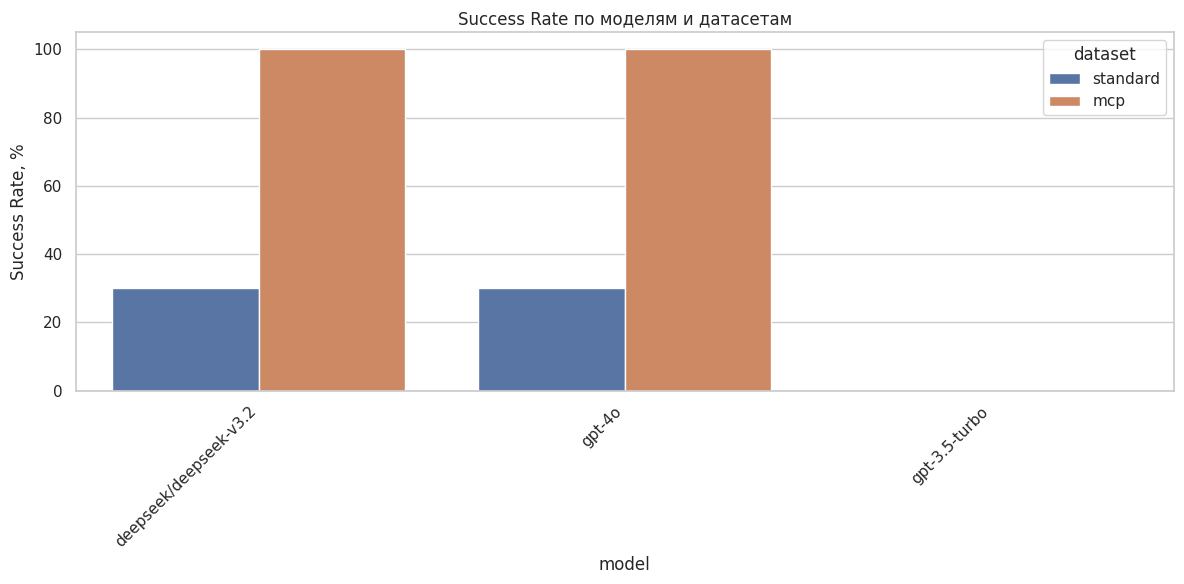

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=results_df,
    x='model',
    y='success_rate_percent',
    hue='dataset',
    ax=ax
)
ax.set_title("Success Rate по моделям и датасетам")
ax.set_ylabel("Success Rate, %")
ax.set_ylim(0, 105)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()